<a href="https://colab.research.google.com/github/Neaviyaa230901069/AIML-lab/blob/main/EXPT_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

path = "/content/drive/MyDrive/EXPT14 - Sheet1 (3).csv"

a = pd.read_csv(path)
a.head(4)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Month,Load (MW),Class
0,1,40,NO
1,2,50,NO
2,3,60,NO
3,4,55,NO


In [ ]:
b = {'NO':0, 'YES':1}
a['Class'] = a['Class'].map(b)

x = a[['Month','Load (MW)']]
y = a[['Class']]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(max_depth=2, random_state=0)

clf.fit(X_train, y_train.values.ravel())

y_pred = clf.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
print("accuracy score",accuracy_score(y_test, y_pred))
print("mean_squared_error",mean_squared_error(y_test, y_pred))
from sklearn.metrics import confusion_matrix

accuracy score 1.0
mean_squared_error 0.0


In [ ]:
from sklearn.metrics import confusion_matrix

data = confusion_matrix(y_true, y_pred, labels=[0,1])
data

array([[17,  0],
       [ 0,  0]])

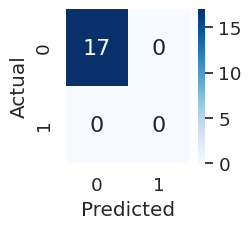

In [ ]:
import seaborn as sn

df_cm = pd.DataFrame(data, columns=[0,1], index=[0,1])

df_cm.index.name = "Actual"
df_cm.columns.name = "Predicted"

plt.figure(figsize=(2,2))
sn.set(font_scale=1.2)
sn.heatmap(df_cm, cmap="Blues", annot=True, annot_kws={"size":16})
plt.show()

In [ ]:
new_month = 20
new_load = 120

new_data = pd.DataFrame([[new_month, new_load]], columns=['Month','Load (MW)'])
new_pred = clf.predict(new_data)

print(new_pred[0])

0
